# SC2001 Project 2 — Dijkstra's Algorithm

This notebook implements and compares:

* **(a)** An adjacency matrix with an unsorted array priority queue.
* **(b)** An array of adjacency lists with an indexed binary minimum heap.
* **(c)** Their theoretical complexity and empirical comparison counts as vertex and edge counts change.

**Model:** directed simple graphs, nonnegative weights, vertices numbered `0` to `V-1`. An undirected graph can be represented by inserting both directed edges. `math.inf` means no edge, so zero-weight edges are supported. Negative weights are rejected because Dijkstra's algorithm requires nonnegative weights.

Run cells from top to bottom. The adjacency matrix uses NumPy; the priority queues and adjacency lists use Python lists. Plots use Matplotlib. Install the dependencies in the notebook environment (`%pip install numpy matplotlib`) if needed. Saved outputs are from a completed local run. Measurements count algorithm-level comparisons rather than elapsed time.

In [1]:
import math
import numpy as np
import random
import statistics
import platform
import sys
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

SEED = 2001
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Random seed:", SEED)

Python: 3.14.7
Platform: macOS-27.0-arm64-arm-64bit-Mach-O
Random seed: 2001


## Graph representations

The adjacency matrix is a NumPy array with shape `(n, n)`; `adj_matrix[u, v]` stores the edge weight, and `np.inf` means no edge. `adj_matrix.shape[0]` gives the number of vertices. Both representations are built from the same edge list outside the timed region. Duplicate edges are rejected to keep the graph model and edge counts unambiguous. Input validation belongs to construction; the algorithm functions assume a valid representation and starting vertex.
The five-vertex example below is instantiated here and reused in parts (a) and (b). Rows are originating vertices and columns are destination vertices; `inf` entries mean no edge, including on the diagonal.

In [2]:
def representations(n, edges):
    if n < 1:
        raise ValueError("At least one vertex is required")
    # In the matrix, inf means no direct edge from the row vertex to the column vertex.
    # Finite entries (including 0) are edge weights; Dijkstra does not modify them.
    adj_matrix = np.full((n, n), np.inf, dtype=float)
    adj_list = [[] for _ in range(n)]
    seen = set()
    for u, v, weight in edges:
        if not (0 <= u < n and 0 <= v < n) or u == v:
            raise ValueError("Invalid endpoint or self-loop")
        if not math.isfinite(weight) or weight < 0:
            raise ValueError("Weights must be finite and nonnegative")
        if (u, v) in seen:
            raise ValueError("Duplicate directed edge")
        seen.add((u, v))
        adj_matrix[u, v] = weight
        adj_list[u].append((v, weight))
    return adj_matrix, adj_list

In [3]:
example = [(0, 1, 10), (0, 2, 3), (2, 1, 1), (1, 3, 2),
           (2, 3, 8), (2, 4, 2), (4, 3, 7), (3, 4, 4)]
example_adj_matrix, example_adj_list = representations(5, example)
example_start_vertex = 0
expected_example = ([0, 4, 3, 6, 5], [None, 2, 0, 1, 2])
print("Sample adjacency matrix (rows/columns: vertices 0–4):")
print(example_adj_matrix)
print("\nSample adjacency lists:")
for u, neighbours in enumerate(example_adj_list):
    print(f"{u}: {neighbours}")

Sample adjacency matrix (rows/columns: vertices 0–4):
[[inf 10.  3. inf inf]
 [inf inf inf  2. inf]
 [inf  1. inf  8.  2.]
 [inf inf inf inf  4.]
 [inf inf inf  7. inf]]

Sample adjacency lists:
0: [(1, 10), (2, 3)]
1: [(3, 2)]
2: [(1, 1), (3, 8), (4, 2)]
3: [(4, 4)]
4: [(3, 7)]


## (a) Adjacency matrix and array priority queue

The implementations share the `initialize` and `relax` functions. `initialize` sets each distance to infinity and each parent to `None`, then sets the starting vertex distance to zero. `relax` updates both the distance and parent when an edge gives a shorter path.

Both Dijkstra implementations initialize distances and parents, add all vertices to `Q`, and while `Q` is nonempty, remove the vertex with minimum distance and relax its outgoing edges. Each returns `(distance, parent)`. A parent of `None` denotes the starting vertex or an unreachable vertex. Equal-distance alternatives keep the existing parent.

For the matrix version, `Q` is an unsorted Python list. `min` scans it to find the minimum-distance vertex, and `remove` deletes that vertex. Each iteration also scans one NumPy matrix row, calling `relax` only for actual edges. The queue is processed until empty, including unreachable vertices.

There are $V$ extractions, each costing $O(V)$, and $V$ row scans of $V$ entries. Priority updates take $O(1)$. Thus **time is $\Theta(V^2)$**, regardless of $E$, and auxiliary space is $O(V)$. The input matrix takes $\Theta(V^2)$ space.

In [4]:
def comparison_counter():
    """Create a fresh counter; pass it to an algorithm to record its decisions."""
    return {"array_min": 0, "array_remove": 0, "edge_exists": 0,
            "relaxation": 0, "heap_order": 0}


def initialize(n, start_vertex):
    """
    Initialize distances and parents.
    The distance to the start vertex is 0; all others are infinite.
    The parent of each vertex is None.
    """
    if not 0 <= start_vertex < n:
        raise ValueError("Invalid start vertex")
    distance = [math.inf] * n
    parent = [None] * n
    distance[start_vertex] = 0  # Reaching the starting vertex itself costs nothing.
    return distance, parent


def relax(u, v, weight, distance, parent, counts=None):
    """Relax edge (u, v); report whether it improved."""
    # Update the tentative path distance and parent; the graph matrix stays unchanged.
    if counts is not None:
        counts["relaxation"] += 1  # Compare the old distance with the candidate.
    if distance[v] > distance[u] + weight:
        parent[v] = u
        distance[v] = distance[u] + weight
        return True
    return False


def dijkstra_matrix(adj_matrix, start_vertex=0, counts=None):
    n = adj_matrix.shape[0]  # One row per vertex.
    distance, parent = initialize(n, start_vertex)
    Q = list(range(n))  # Unsorted array priority queue of all vertices.
    while Q:
        if counts is not None:
            counts["array_min"] += len(Q) - 1  # min compares k priorities k−1 times.
        u = min(Q, key=lambda vertex: distance[vertex])
        if counts is not None:
            # Instrument the same left-to-right search as list.remove, then delete.
            # Count each vertex equality decision; shifting elements is not a comparison.
            for i, vertex in enumerate(Q):
                counts["array_remove"] += 1
                if vertex == u:
                    del Q[i]
                    break
        else:
            Q.remove(u)
        for v, weight in enumerate(adj_matrix[u]):
            if counts is not None:
                counts["edge_exists"] += 1  # Includes checks for absent edges.
            if weight != np.inf:  # Process existing edges. Inf means no edge from u to v.
                relax(u, v, weight, distance, parent, counts)
    return distance, parent

### (a) Test the sample matrix

Run the implementation on the matrix instantiated above, starting at vertex 0. The expected distances are `[0, 4, 3, 6, 5]`; for example, the shortest route to vertex 3 is `0 → 2 → 1 → 3`, with weight `3 + 1 + 2 = 6`. The assertion checks both distances and parents.

In [5]:
matrix_example_counts = comparison_counter()
matrix_example_result = dijkstra_matrix(example_adj_matrix, example_start_vertex, counts=matrix_example_counts)
assert matrix_example_result == expected_example
print("Matrix shortest distances:", [float(value) for value in matrix_example_result[0]])
print("Matrix parents:", matrix_example_result[1])
print("Sample matrix test passed.")
print("Matrix comparison breakdown:", matrix_example_counts)
print("Total comparisons:", sum(matrix_example_counts.values()))

Matrix shortest distances: [0.0, 4.0, 3.0, 6.0, 5.0]
Matrix parents: [None, 2, 0, 1, 2]
Sample matrix test passed.
Matrix comparison breakdown: {'array_min': 10, 'array_remove': 7, 'edge_exists': 25, 'relaxation': 8, 'heap_order': 0}
Total comparisons: 50


### (a) Empirical comparison counts

Measure comparison counts for the matrix implementation, then repeat the same experiment for the heap in part (b).

The counting unit is one **algorithm-level decision**, not every low-level Python instruction:

| Counter | Decision counted |
|---|---|
| `array_min` | One priority comparison during array extract-min; a queue of k vertices uses k−1 comparisons |
| `array_remove` | One vertex equality check during the left-to-right removal search |
| `edge_exists` | One `weight != np.inf` check per matrix entry, including absent edges |
| `relaxation` | One old-distance versus candidate-distance comparison per actual edge |
| `heap_order` | One heap ordering comparison between `(priority, vertex ID)` pairs, including heap construction |

The heap pair comparison counts as one ordering decision even when the vertex ID breaks a tie. Validation, loop conditions, index/bounds checks, and the counter's own bookkeeping are excluded. Arithmetic, swaps, assignments, and list shifts are operations but are not comparisons. Thus this measures a specified kind of algorithmic work, not complete runtime cost. Both algorithms count the same relaxation decision.

1. Generate directed graphs with exact edge counts and weights from 1 to 100. A chain ensures all vertices are reachable from starting vertex 0; additional edges are sampled without replacement. This introduces a deliberate connectivity bias.
2. Build both representations from identical edges. Exclude construction and validation comparisons.
3. Count one execution on each of three independently seeded graphs per setting. Report the median total count and the minimum–maximum across graphs. Repeating the same graph would give the same count, so timing repetitions and warm-ups are unnecessary. The range reflects graph variation, not machine timing noise.
4. Test 15 vertex counts for sparse graphs (`E = 3V`) and dense graphs (`E ≈ 0.3V(V−1)`), and 15 edge counts at `V = 250`. Part (b) verifies both algorithms agree on every graph.

The optional `counts` parameter preserves the usual `(distance, parent)` return value. Omitting it runs the algorithm without recording comparisons.

In [6]:
VERTICES = list(range(50, 401, 25))  # 15 measured vertex counts.
GRAPH_TRIALS = 3

# Generate a random directed graph with n vertices and m edges.
def random_graph(n, m, seed):
    if not n - 1 <= m <= n * (n - 1):
        raise ValueError("Edge count incompatible with reachable simple graph")
    rng = random.Random(seed)
    chain = [(u, u + 1) for u in range(n - 1)]
    chain_set = set(chain)
    candidates = [(u, v) for u in range(n) for v in range(n)
                  if u != v and (u, v) not in chain_set]
    pairs = chain + rng.sample(candidates, m - len(chain))
    return [(u, v, rng.randint(1, 100)) for u, v in pairs]


FIXED_V = 250
capacity = FIXED_V * (FIXED_V - 1)
EDGE_COUNTS = sorted({FIXED_V - 1, 2 * FIXED_V, 4 * FIXED_V, 8 * FIXED_V,
                      *(round(density * capacity) for density in np.linspace(0.05, 0.7, 11))})
# 15 measured edge counts, including very sparse graphs.

def make_setting(n, m, seed):
    graphs = [representations(n, random_graph(n, m, seed + trial))
              for trial in range(GRAPH_TRIALS)]
    return {'V': n, 'E': m, 'density': m / (n * (n - 1)), 'graphs': graphs}

vertex_settings = {}
for family in ['sparse', 'dense']:
    vertex_settings[family] = []
    for n in VERTICES:
        m = 3 * n if family == 'sparse' else round(0.3 * n * (n - 1))
        vertex_settings[family].append(make_setting(
            n, m, SEED + n * 100 + (0 if family == 'sparse' else 100000)))
edge_settings = [make_setting(FIXED_V, m, SEED + m) for m in EDGE_COUNTS]

def benchmark_algorithm(setting, algorithm, representation_index, name):
    totals, breakdowns = [], []
    for graphs in setting['graphs']:
        counts = comparison_counter()
        algorithm(graphs[representation_index], start_vertex=0, counts=counts)
        totals.append(sum(counts.values()))
        breakdowns.append(counts)
    return {**{key: setting[key] for key in ['V', 'E', 'density']},
            name: statistics.median(totals),
            name + '_min': min(totals), name + '_max': max(totals),
            name + '_breakdown': breakdowns}

def print_algorithm_table(title, rows, name):
    print(title)
    print(f"{'V':>5} {'E':>8} {'density':>9} {'total comparisons [min,max]':>35}")
    for r in rows:
        value = f"{r[name]:,.0f} [{r[name + '_min']:,},{r[name + '_max']:,}]"
        print(f"{r['V']:5d} {r['E']:8d} {r['density']:9.3f} {value:>35}")
    print()

In [7]:
def chart(title, xlabel, series):
    """Plot comparison counts and theoretical references on linear axes."""
    fig, ax = plt.subplots(figsize=(9, 4.8), layout='constrained')
    for name, points, color, dashed in series:
        x, y = zip(*points)
        ax.plot(x, y, label=name, color=color, linewidth=2,
                linestyle='--' if dashed else '-',
                marker=None if dashed else 'o', markersize=5)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Median comparisons')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
    plt.show()
    plt.close(fig)


def log_slope(rows, name):
    x = [math.log(r['V']) for r in rows]
    y = [math.log(r[name]) for r in rows]
    mx, my = statistics.mean(x), statistics.mean(y)
    return sum((a - mx) * (b - my) for a, b in zip(x, y)) / sum((a - mx) ** 2 for a in x)

The charts use linear axes starting at zero. Each solid marker is the median comparison count across three graphs at one measured setting; lines connect the 15 settings. Dashed curves are theoretical growth shapes scaled to the first count, not exact formulas or fitted predictions. The heap reference uses the shape from the asymptotic upper bound, but its empirical scaling does not make the drawn curve a guaranteed numerical upper bound. For either algorithm, the plotted reference is C(V) = C(V₀) × f(V,E) / f(V₀,E₀), where C(V₀) is the first measured median count and f is the indicated growth formula. Normalized counts and descriptive log-log slopes summarize growth numerically, although the graphs themselves use linear axes.

In [8]:
matrix_vertex_results = {
    family: [benchmark_algorithm(setting, dijkstra_matrix, 0, 'matrix')
             for setting in settings]
    for family, settings in vertex_settings.items()
}
matrix_edge_results = [benchmark_algorithm(setting, dijkstra_matrix, 0, 'matrix')
                       for setting in edge_settings]
for family, rows in matrix_vertex_results.items():
    print_algorithm_table(f"Matrix + array: {family} vertex sweep", rows, 'matrix')
print_algorithm_table("Matrix + array: edge sweep at V = 250", matrix_edge_results, 'matrix')

Matrix + array: sparse vertex sweep
    V        E   density         total comparisons [min,max]
   50      150     0.061                 4,495 [4,329,4,538]
   75      225     0.041                9,984 [9,905,10,100]
  100      300     0.030              17,577 [17,206,17,735]
  125      375     0.024              27,516 [26,906,27,534]
  150      450     0.020              39,546 [39,304,39,999]
  175      525     0.017              53,511 [53,297,53,690]
  200      600     0.015              70,437 [69,753,70,537]
  225      675     0.013              88,949 [88,774,89,279]
  250      750     0.012           109,910 [108,986,110,017]
  275      825     0.011           132,164 [132,148,132,957]
  300      900     0.010           157,817 [156,857,158,302]
  325      975     0.009           184,079 [183,964,185,187]
  350     1050     0.009           214,948 [211,096,216,406]
  375     1125     0.008           248,387 [245,348,249,449]
  400     1200     0.008           277,696 [276,4

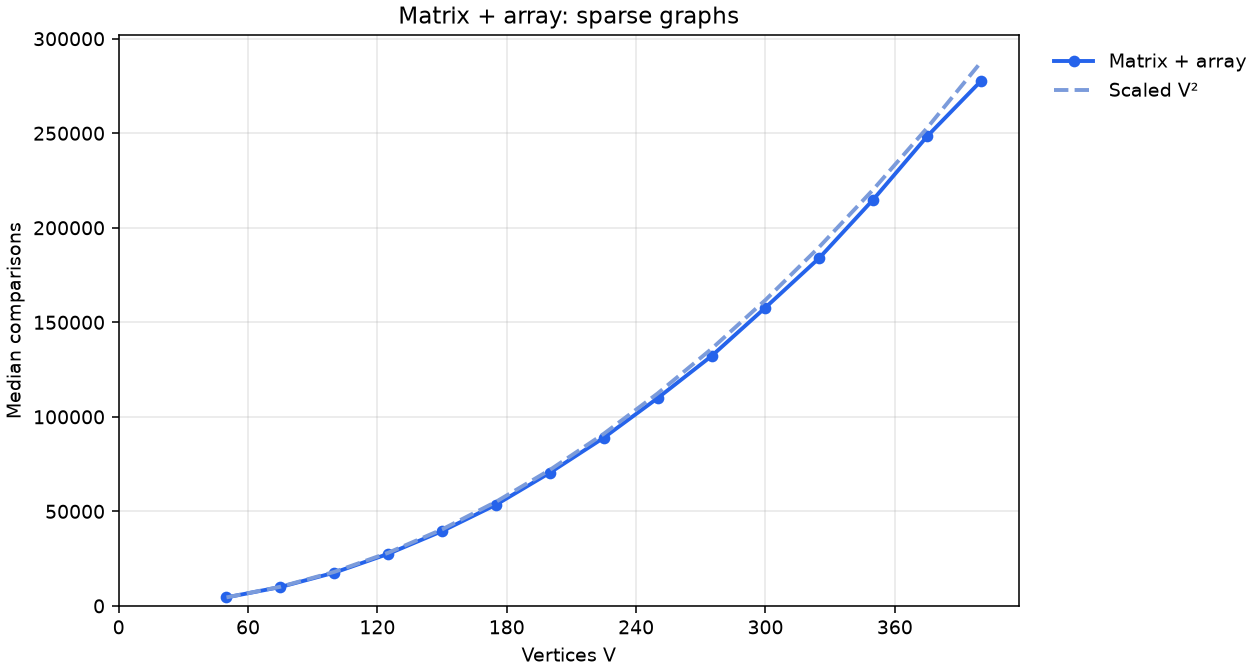

In [9]:
family = 'sparse'
rows = matrix_vertex_results[family]
first = rows[0]
shape = lambda r: r['V'] ** 2
chart(f"Matrix + array: {family} graphs", "Vertices V", [
    ('Matrix + array', [(r['V'], r['matrix']) for r in rows], '#2563eb', False),
    ('Scaled V²', [(r['V'], first['matrix'] * shape(r) / shape(first)) for r in rows], '#7b9bdb', True)])

**Analysis:** As V increases from 50 to 400, median matrix comparisons increase from **4,495 to 277,696** (61.8×). The matrix performs exactly **160,000 edge-existence checks**, **79,800 minimum-search comparisons**, and **1,200 relaxation comparisons** at the last setting. These scans explain the quadratic growth even when most matrix entries are absent. The scaled V² curve shows the dominant growth shape; removal-search order and the E relaxation term explain deviations from that reference. Counts are deterministic for a fixed graph; the reported range comes from different graphs.

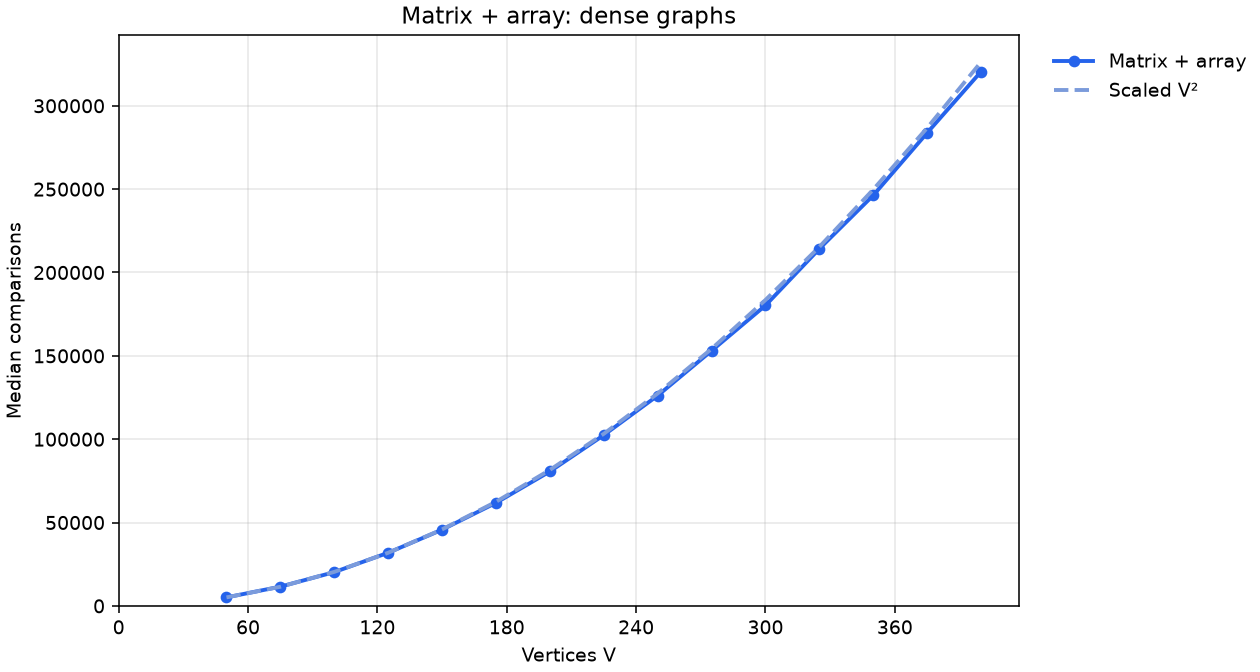

In [10]:
family = 'dense'
rows = matrix_vertex_results[family]
first = rows[0]
shape = lambda r: r['V'] ** 2
chart(f"Matrix + array: {family} graphs", "Vertices V", [
    ('Matrix + array', [(r['V'], r['matrix']) for r in rows], '#2563eb', False),
    ('Scaled V²', [(r['V'], first['matrix'] * shape(r) / shape(first)) for r in rows], '#7b9bdb', True)])

**Analysis:** As V increases from 50 to 400, median matrix comparisons increase from **5,098 to 320,534** (62.9×). The matrix performs exactly **160,000 edge-existence checks**, **79,800 minimum-search comparisons**, and **47,880 relaxation comparisons** at the last setting. Here E also grows quadratically, so relaxation comparisons add another quadratic term. Total comparison growth remains Θ(V²). Deviations from the scaled reference reflect changing removal-search order and the exact edge-count formula, rather than timing noise. Counts are deterministic for a fixed graph; the reported range comes from different graphs.

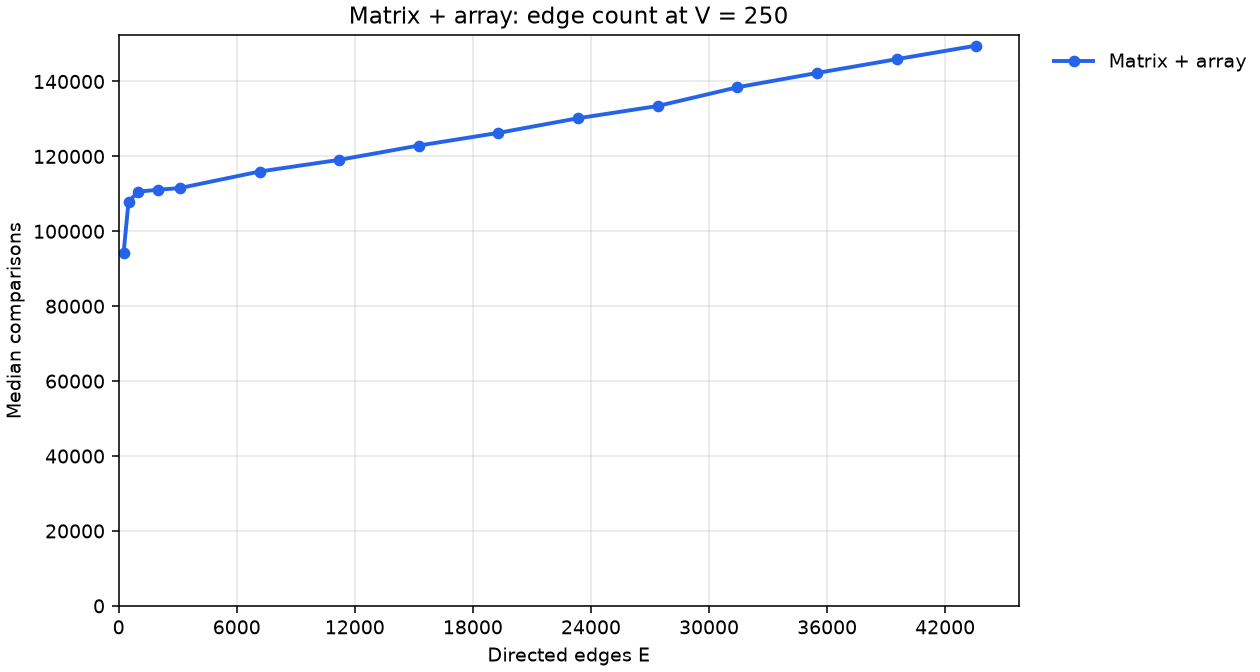

In [11]:
chart("Matrix + array: edge count at V = 250", "Directed edges E", [
    ('Matrix + array', [(r['E'], r['matrix']) for r in matrix_edge_results], '#2563eb', False)])

**Analysis:** At V = 250, E increases from 249 to 43,575, median matrix comparisons increase from **94,124 to 149,576** (1.6×). The matrix performs exactly **62,500 edge-existence checks**, **31,125 minimum-search comparisons**, and **43,575 relaxation comparisons** at the last setting. The first two components stay fixed throughout this edge sweep. Additional edges add relaxation comparisons, while graph-dependent extraction order can change the removal-search count. This isolates connectivity from vertex count. Counts are deterministic for a fixed graph; the reported range comes from different graphs.

In [12]:
for family, rows in matrix_vertex_results.items():
    print(f"{family}: descriptive log-log slope = {log_slope(rows, 'matrix'):.2f}")
    print("  Comparisons / V²:", [round(r['matrix'] / r['V']**2, 7) for r in rows])

sparse: descriptive log-log slope = 1.99
  Comparisons / V²: [1.798, 1.7749333, 1.7577, 1.761024, 1.7576, 1.747298, 1.760925, 1.7570173, 1.75856, 1.7476231, 1.7535222, 1.7427598, 1.7546776, 1.7663076, 1.7356]
dense: descriptive log-log slope = 1.99
  Comparisons / V²: [2.0392, 2.0535111, 2.0259, 2.039232, 2.0311111, 2.0177306, 2.015525, 2.0235654, 2.018368, 2.0237488, 2.0026444, 2.0283456, 2.0106531, 2.0180409, 2.0033375]


For the matrix implementation, `edge_exists = V²`, `array_min = V(V−1)/2`, and `relaxation = E` exactly, because all vertices are processed. The removal search adds between V and V(V+1)/2 equality decisions depending on extraction order. The total therefore remains Θ(V²). At fixed V, only the edge-relaxation count and removal-search order can change.

## (b) Adjacency lists and a minimum heap

The heap contains at most one entry per vertex. A position array supports **decrease-key**, so an improved distance updates the existing entry. This avoids the stale duplicate entries used in a common `heapq` implementation. The heap starts with all vertices, is built in $O(V)$ time, and is processed until empty. When `relax` improves a distance, `decrease_key` restores heap order. With nonnegative weights, an extracted vertex cannot subsequently receive a shorter distance.

In [13]:
class IndexedMinHeap:
    """Binary heap of vertex IDs, ordered by (priority, vertex ID)."""
    def __init__(self, priorities, counts=None):
        self.counts = counts
        self.key = list(priorities)
        self.heap = list(range(len(priorities)))
        self.position = list(range(len(priorities)))
        for i in range(len(self.heap) // 2 - 1, -1, -1):
            self._down(i)

    def __bool__(self):
        return bool(self.heap)

    def _less(self, i, j):
        if self.counts is not None:
            self.counts["heap_order"] += 1  # One ordering decision, including tie-breaking.
        u, v = self.heap[i], self.heap[j]
        return (self.key[u], u) < (self.key[v], v)

    def _swap(self, i, j):
        self.heap[i], self.heap[j] = self.heap[j], self.heap[i]
        self.position[self.heap[i]] = i
        self.position[self.heap[j]] = j

    def _down(self, i):
        while 2 * i + 1 < len(self.heap):
            child = 2 * i + 1
            if child + 1 < len(self.heap) and self._less(child + 1, child):
                child += 1
            if not self._less(child, i):
                break
            self._swap(i, child)
            i = child

    def decrease_key(self, vertex, priority):
        i = self.position[vertex]
        if i < 0 or priority > self.key[vertex]:
            raise ValueError("Vertex removed or priority increased")
        self.key[vertex] = priority
        while i > 0:
            parent = (i - 1) // 2
            if not self._less(i, parent):
                break
            self._swap(i, parent)
            i = parent

    def pop_min(self):
        if not self.heap:
            raise IndexError("Empty heap")
        vertex = self.heap[0]
        last = self.heap.pop()
        self.position[vertex] = -1
        if self.heap:
            self.heap[0] = last
            self.position[last] = 0
            self._down(0)
        return vertex, self.key[vertex]


def dijkstra_heap(adj_list, start_vertex=0, counts=None):
    n = len(adj_list)
    distance, parent = initialize(n, start_vertex)
    Q = IndexedMinHeap(distance, counts)  # Priority queue of all vertices.
    while Q:
        u, _ = Q.pop_min()
        for v, weight in adj_list[u]:
            if relax(u, v, weight, distance, parent, counts):
                Q.decrease_key(v, distance[v])
    return distance, parent

### (b) Test the sample adjacency lists

Use the adjacency lists built from the same example in “Graph representations.” Check the expected distances and parents, and verify that the heap agrees with part (a).

In [14]:
heap_example_counts = comparison_counter()
heap_example_result = dijkstra_heap(example_adj_list, example_start_vertex, counts=heap_example_counts)
assert heap_example_result == expected_example == matrix_example_result
print("Heap shortest distances:", heap_example_result[0])
print("Heap parents:", heap_example_result[1])
print("Sample heap test passed; results agree with part (a).")
print("Heap comparison breakdown:", heap_example_counts)
print("Total comparisons:", sum(heap_example_counts.values()))

Heap shortest distances: [0, 4, 3, 6, 5]
Heap parents: [None, 2, 0, 1, 2]
Sample heap test passed; results agree with part (a).
Heap comparison breakdown: {'array_min': 0, 'array_remove': 0, 'edge_exists': 0, 'relaxation': 8, 'heap_order': 14}
Total comparisons: 22


Heap construction costs $O(V)$. At most $V$ extract-min operations and at most $E$ successful decrease-key operations cost $O(\log V)$ each. Each adjacency entry is scanned at most once, costing $O(E)$ overall. Hence **time is $O((V+E)\log V)$** (for $V\ge2$), auxiliary space is $O(V)$, and the graph uses $O(V+E)$ space.

This is an upper bound, not a claim that every input requires $E\log V$ work. Many edges do not improve a tentative distance and cause no heap update. In dense random graphs, the actual number of decrease-key operations can be far smaller than $E$.

Why Dijkstra works: after extracting the smallest tentative distance, any alternative route through an unsettled vertex has distance at least that minimum because weights are nonnegative. The extracted distance is therefore final. Relaxation preserves tentative distances as lengths of discovered paths. Both implementations follow this same invariant.

### (b) Additional correctness checks

An independent Bellman–Ford reference verifies shortest distances. Checks cover a known example, disconnected vertices, zero-weight edges, one vertex, invalid weights, randomized graphs, and the heap's ordering and position bookkeeping.

In [15]:
def bellman_ford(n, edges, start_vertex=0):
    distance = [math.inf] * n
    distance[start_vertex] = 0
    for _ in range(n - 1):
        changed = False
        for u, v, weight in edges:
            if distance[u] + weight < distance[v]:
                distance[v] = distance[u] + weight
                changed = True
        if not changed:
            break
    return distance

cases = [(1, []), (4, []), (4, [(0, 1, 0), (1, 2, 0)]),
         (4, [(0, 1, 9), (0, 2, 1), (2, 1, 1), (1, 3, 1)])]
rng = random.Random(SEED)
for n in range(2, 26):
    for _ in range(5):
        edges = [(u, v, rng.randrange(11)) for u in range(n)
                 for v in range(n) if u != v and rng.random() < 0.2]
        cases.append((n, edges))
checks = 0
for n, edges in cases:
    adj_matrix, adj_list = representations(n, edges)
    for start_vertex in {0, n - 1}:
        expected = bellman_ford(n, edges, start_vertex)
        for algorithm, graph in [(dijkstra_matrix, adj_matrix), (dijkstra_heap, adj_list)]:
            counts = comparison_counter()
            distance, parent = algorithm(graph, start_vertex, counts=counts)
            assert (distance, parent) == algorithm(graph, start_vertex)
            assert counts['relaxation'] == len(edges)
            if algorithm is dijkstra_matrix:
                assert counts['edge_exists'] == n * n
                assert counts['array_min'] == n * (n - 1) // 2
                assert n <= counts['array_remove'] <= n * (n + 1) // 2
                assert counts['heap_order'] == 0
            else:
                assert counts['array_min'] == counts['array_remove'] == counts['edge_exists'] == 0
            assert distance == expected
            assert parent[start_vertex] is None
            for v in range(n):
                if v == start_vertex or distance[v] == math.inf:
                    assert parent[v] is None
                    continue
                # The parent edges must form a shortest path back to the start vertex.
                current, visited, path_weight = v, set(), 0
                while current != start_vertex:
                    assert current not in visited
                    visited.add(current)
                    u = parent[current]
                    assert u is not None and adj_matrix[u, current] != np.inf
                    path_weight += adj_matrix[u, current]
                    current = u
                assert path_weight == distance[v]
        checks += 1

queue = IndexedMinHeap([9, 4, 7, 2, 11])
queue.decrease_key(4, 0)
queue.decrease_key(0, 1)
assert [queue.pop_min()[0] for _ in range(5)] == [4, 0, 3, 1, 2]
assert queue.position == [-1] * 5
for weight in [-1, math.inf, math.nan]:
    try:
        representations(2, [(0, 1, weight)])
    except ValueError:
        pass
    else:
        raise AssertionError("Invalid weight accepted")
print(f"Passed {checks} graph/start-vertex cases, parent-path checks, heap checks, and invalid-weight checks.")

# Hand-counted two-vertex graph: matrix 1 min + 2 removal + 4 edge + 1 relaxation.
tiny_matrix, tiny_list = representations(2, [(0, 1, 5)])
matrix_counts, heap_counts = comparison_counter(), comparison_counter()
assert dijkstra_matrix(tiny_matrix, counts=matrix_counts) == dijkstra_heap(tiny_list, counts=heap_counts)
assert matrix_counts == {'array_min': 1, 'array_remove': 2, 'edge_exists': 4,
                         'relaxation': 1, 'heap_order': 0}
# Heap: one construction ordering decision and one relaxation comparison.
assert heap_counts == {'array_min': 0, 'array_remove': 0, 'edge_exists': 0,
                       'relaxation': 1, 'heap_order': 1}
print("Counted/uncounted results and comparison-count invariants passed.")

Passed 247 graph/start-vertex cases, parent-path checks, heap checks, and invalid-weight checks.
Counted/uncounted results and comparison-count invariants passed.


### (b) Empirical comparison counts

Reuse the same three graphs per setting and the same starting vertex as part (a). Count heap ordering decisions and the distance comparison in each relaxation. Unlike the matrix, the adjacency lists need no checks for absent edges. Before collecting counts, verify that both implementations return identical distances and parents on every graph.

In [16]:
for settings in [*vertex_settings.values(), edge_settings]:
    for setting in settings:
        for adj_matrix, adj_list in setting['graphs']:
            assert dijkstra_matrix(adj_matrix) == dijkstra_heap(adj_list)
print("Both implementations agree on all benchmark graphs.")

Both implementations agree on all benchmark graphs.


In [17]:
heap_vertex_results = {
    family: [benchmark_algorithm(setting, dijkstra_heap, 1, 'heap')
             for setting in settings]
    for family, settings in vertex_settings.items()
}
heap_edge_results = [benchmark_algorithm(setting, dijkstra_heap, 1, 'heap')
                       for setting in edge_settings]
for family, rows in heap_vertex_results.items():
    print_algorithm_table(f"Lists + heap: {family} vertex sweep", rows, 'heap')
print_algorithm_table("Lists + heap: edge sweep at V = 250", heap_edge_results, 'heap')

Lists + heap: sparse vertex sweep
    V        E   density         total comparisons [min,max]
   50      150     0.061                       659 [655,676]
   75      225     0.041                 1,086 [1,076,1,098]
  100      300     0.030                 1,519 [1,512,1,561]
  125      375     0.024                 1,991 [1,974,2,054]
  150      450     0.020                 2,470 [2,466,2,490]
  175      525     0.017                 2,967 [2,934,2,988]
  200      600     0.015                 3,486 [3,485,3,497]
  225      675     0.013                 4,039 [4,010,4,051]
  250      750     0.012                 4,523 [4,517,4,570]
  275      825     0.011                 5,047 [5,038,5,078]
  300      900     0.010                 5,599 [5,596,5,609]
  325      975     0.009                 6,199 [6,145,6,209]
  350     1050     0.009                 6,678 [6,606,6,709]
  375     1125     0.008                 7,255 [7,233,7,284]
  400     1200     0.008                 7,795 [7,7

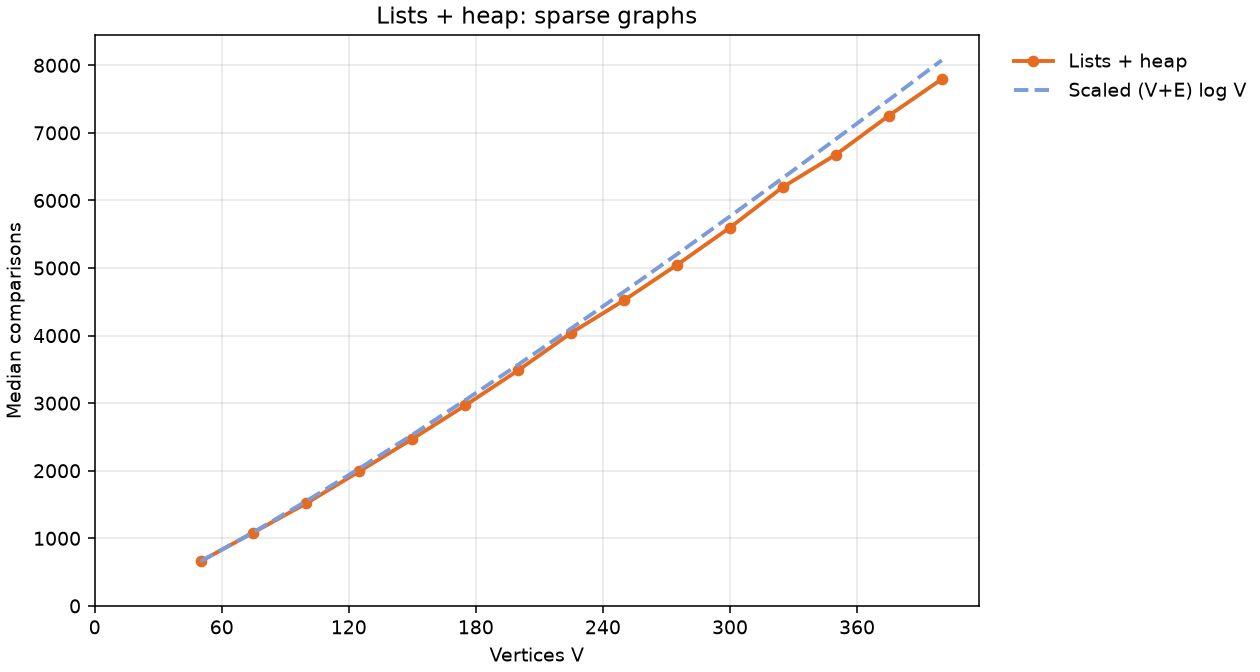

In [18]:
family = 'sparse'
rows = heap_vertex_results[family]
first = rows[0]
shape = lambda r: (r['V'] + r['E']) * math.log2(r['V'])
chart(f"Lists + heap: {family} graphs", "Vertices V", [
    ('Lists + heap', [(r['V'], r['heap']) for r in rows], '#e56b20', False),
    ('Scaled (V+E) log V', [(r['V'], first['heap'] * shape(r) / shape(first)) for r in rows], '#7b9bdb', True)])

**Analysis:** As V increases from 50 to 400, median heap comparisons increase from **659 to 7,795** (11.8×). At the last setting, relaxation contributes exactly **1,200 comparisons**, and the median heap ordering count is **6,595**. With E = 3V, the theoretical comparison bound is O(V log V). Processing only actual adjacency entries avoids the quadratic absent-edge checks of the matrix. The dashed reference scales the (V+E) log V growth shape to the first measured count; it is neither an exact predicted count nor a guaranteed numerical upper bound. Counts are deterministic for a fixed graph; the reported range comes from different graphs.

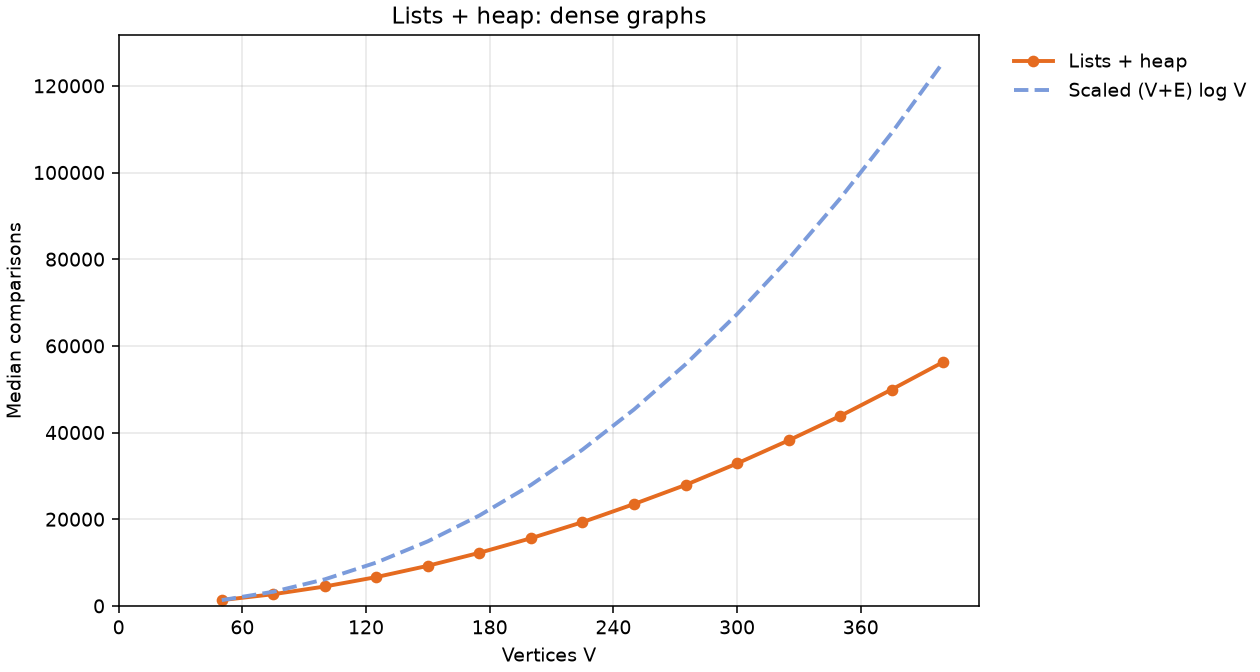

In [19]:
family = 'dense'
rows = heap_vertex_results[family]
first = rows[0]
shape = lambda r: (r['V'] + r['E']) * math.log2(r['V'])
chart(f"Lists + heap: {family} graphs", "Vertices V", [
    ('Lists + heap', [(r['V'], r['heap']) for r in rows], '#e56b20', False),
    ('Scaled (V+E) log V', [(r['V'], first['heap'] * shape(r) / shape(first)) for r in rows], '#7b9bdb', True)])

**Analysis:** As V increases from 50 to 400, median heap comparisons increase from **1,332 to 56,268** (42.2×). At the last setting, relaxation contributes exactly **47,880 comparisons**, and the median heap ordering count is **8,388**. With E ≈ 0.3V(V−1), relaxation work grows quadratically. The worst-case O(V² log V) analysis allows a heap update for every edge, but many edges do not improve distances and require no decrease-key. The dashed line illustrates that growth shape, scaled to the first measurement; it is not an exact comparison formula or a guaranteed numerical upper bound. Counts are deterministic for a fixed graph; the reported range comes from different graphs.

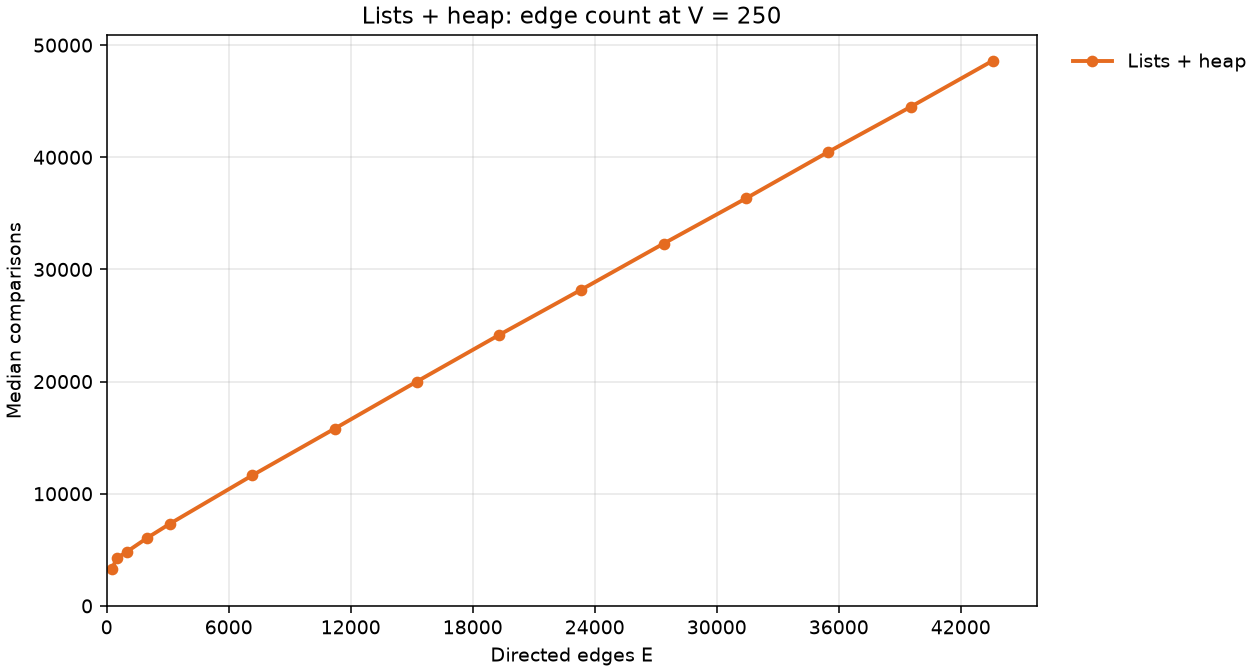

In [20]:
chart("Lists + heap: edge count at V = 250", "Directed edges E", [
    ('Lists + heap', [(r['E'], r['heap']) for r in heap_edge_results], '#e56b20', False)])

**Analysis:** At V = 250, E increases from 249 to 43,575, median heap comparisons increase from **3,256 to 48,615** (14.9×). At the last setting, relaxation contributes exactly **43,575 comparisons**, and the median heap ordering count is **5,040**. Every added edge contributes one relaxation comparison. Heap ordering work also depends on successful decrease-key operations and extraction order, so total growth need not be directly proportional to E. No comparisons are spent checking absent edges. Counts are deterministic for a fixed graph; the reported range comes from different graphs.

In [21]:
for family, rows in heap_vertex_results.items():
    print(f"{family}: descriptive log-log slope = {log_slope(rows, 'heap'):.2f}")
    print("  Comparisons / ((V+E) log₂V):", [round(r['heap'] / ((r['V'] + r['E']) * math.log2(r['V'])), 7) for r in rows])

sparse: descriptive log-log slope = 1.19
  Comparisons / ((V+E) log₂V): [0.5838207, 0.5811696, 0.5715807, 0.5716514, 0.5694799, 0.5688433, 0.5700657, 0.5743414, 0.5678035, 0.5662124, 0.5670113, 0.5714636, 0.5644161, 0.5656426, 0.5636229]
dense: descriptive log-log slope = 1.81
  Comparisons / ((V+E) log₂V): [0.3006482, 0.2485665, 0.2193989, 0.19987, 0.1867475, 0.1765585, 0.1681962, 0.1610976, 0.1558913, 0.1504936, 0.1467758, 0.1433978, 0.1401236, 0.1375478, 0.13483]


For the heap, the relaxation count is exactly E, while heap ordering counts depend on extraction and decrease-key operations. Sparse graphs have E = 3V, giving an O(V log V) comparison upper bound. Dense graphs have Θ(V²) edges, giving an O(V² log V) upper bound; many edges cause no decrease-key, so observed counts may grow more slowly than this scaled growth reference. At fixed V, the E relaxation comparisons provide a predictable increase as edges are added.

## (c) Comparison and interpretation

Compare counts from parts (a) and (b) on identical graphs. The ratio `matrix/heap > 1` means the matrix used more counted comparisons. This ratio is not a runtime speedup: the counted decisions and uncounted operations can have different costs.

In [22]:
def combine_results(matrix_rows, heap_rows):
    combined = []
    for a, b in zip(matrix_rows, heap_rows):
        assert (a['V'], a['E']) == (b['V'], b['E'])
        combined.append({**a, **b, 'comparison_ratio': a['matrix'] / b['heap']})
    return combined

vertex_results = {family: combine_results(matrix_vertex_results[family], heap_vertex_results[family])
                  for family in vertex_settings}
edge_results = combine_results(matrix_edge_results, heap_edge_results)

In [23]:
def print_table(title, rows):
    print(title)
    print(f"{'V':>5} {'E':>8} {'matrix comparisons':>20} {'heap comparisons':>20} {'matrix/heap':>12}")
    for r in rows:
        print(f"{r['V']:5d} {r['E']:8d} {r['matrix']:20,.0f} {r['heap']:20,.0f} {r['comparison_ratio']:12.2f}")
    print()

for family, rows in vertex_results.items():
    print_table(f"V sweep: {family} graphs", rows)
print_table(f"E sweep: V = {FIXED_V}", edge_results)
print("matrix/heap > 1 means the heap used fewer comparisons; this is not a timing ratio.")

V sweep: sparse graphs
    V        E   matrix comparisons     heap comparisons  matrix/heap
   50      150                4,495                  659         6.82
   75      225                9,984                1,086         9.19
  100      300               17,577                1,519        11.57
  125      375               27,516                1,991        13.82
  150      450               39,546                2,470        16.01
  175      525               53,511                2,967        18.04
  200      600               70,437                3,486        20.21
  225      675               88,949                4,039        22.02
  250      750              109,910                4,523        24.30
  275      825              132,164                5,047        26.19
  300      900              157,817                5,599        28.19
  325      975              184,079                6,199        29.69
  350     1050              214,948                6,678        32.

### Comparing measured growth

These Matplotlib plots compare median comparison counts on linear axes. Each series contains 15 measured settings. Dashed curves illustrate scaled theoretical growth shapes. Log-log slopes below are numerical summaries of comparison growth, not a change to the plot axes.

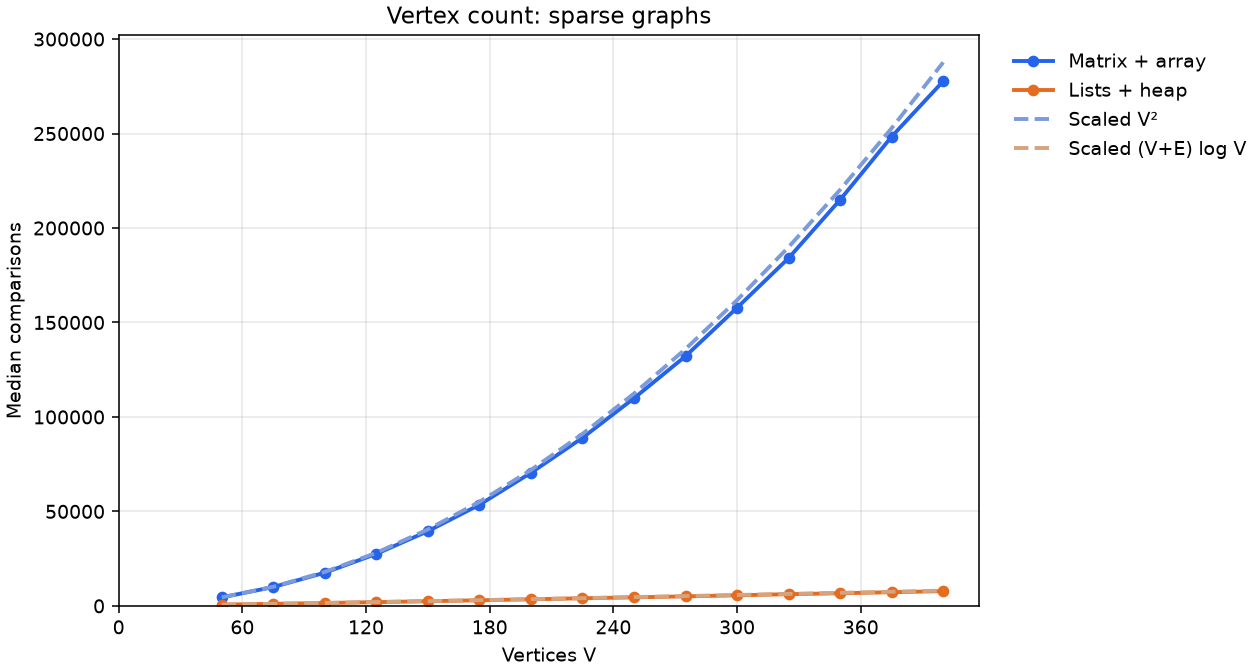

In [24]:
family = 'sparse'
rows = vertex_results[family]
first = rows[0]
matrix_ref = lambda r: first['matrix'] * (r['V'] / first['V']) ** 2
heap_shape = lambda r: (r['V'] + r['E']) * math.log2(r['V'])
chart(f"Vertex count: {family} graphs", "Vertices V", [
    ('Matrix + array', [(r['V'], r['matrix']) for r in rows], '#2563eb', False),
    ('Lists + heap', [(r['V'], r['heap']) for r in rows], '#e56b20', False),
    ('Scaled V²', [(r['V'], matrix_ref(r)) for r in rows], '#7b9bdb', True),
    ('Scaled (V+E) log V', [(r['V'], first['heap'] * heap_shape(r) / heap_shape(first)) for r in rows], '#d5a37e', True)])

**Analysis:** As V increases from 50 to 400, matrix counts change from **4,495 to 277,696**, while heap counts change from **659 to 7,795**. The matrix/heap comparison ratio changes from **6.8× to 35.6×**. The sparse workload exposes the matrix's quadratic scans and the heap's benefit from processing only actual edges. The measured comparison gap supports the O(V log V) versus Θ(V²) distinction for E = 3V. A smaller count means fewer defined decisions, not necessarily proportionally faster execution. Counts are deterministic for a fixed graph; the reported range comes from different graphs.

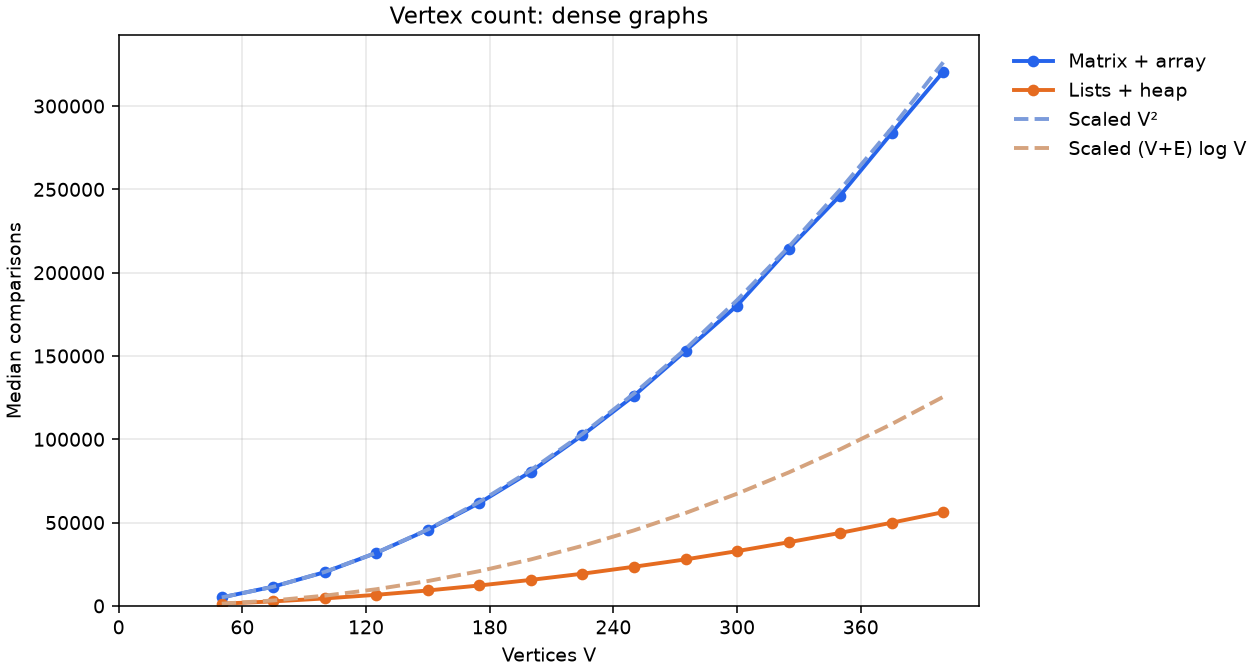

In [25]:
family = 'dense'
rows = vertex_results[family]
first = rows[0]
matrix_ref = lambda r: first['matrix'] * (r['V'] / first['V']) ** 2
heap_shape = lambda r: (r['V'] + r['E']) * math.log2(r['V'])
chart(f"Vertex count: {family} graphs", "Vertices V", [
    ('Matrix + array', [(r['V'], r['matrix']) for r in rows], '#2563eb', False),
    ('Lists + heap', [(r['V'], r['heap']) for r in rows], '#e56b20', False),
    ('Scaled V²', [(r['V'], matrix_ref(r)) for r in rows], '#7b9bdb', True),
    ('Scaled (V+E) log V', [(r['V'], first['heap'] * heap_shape(r) / heap_shape(first)) for r in rows], '#d5a37e', True)])

**Analysis:** As V increases from 50 to 400, matrix counts change from **5,098 to 320,534**, while heap counts change from **1,332 to 56,268**. The matrix/heap comparison ratio changes from **3.8× to 5.7×**. Dense graphs give both algorithms Θ(V²) relaxation comparisons. The heap can still use fewer total comparisons because it avoids matrix edge-existence checks and many edges cause no heap update. Its larger worst-case upper bound does not require larger counts on these particular inputs. A smaller count means fewer defined decisions, not necessarily proportionally faster execution. Counts are deterministic for a fixed graph; the reported range comes from different graphs.

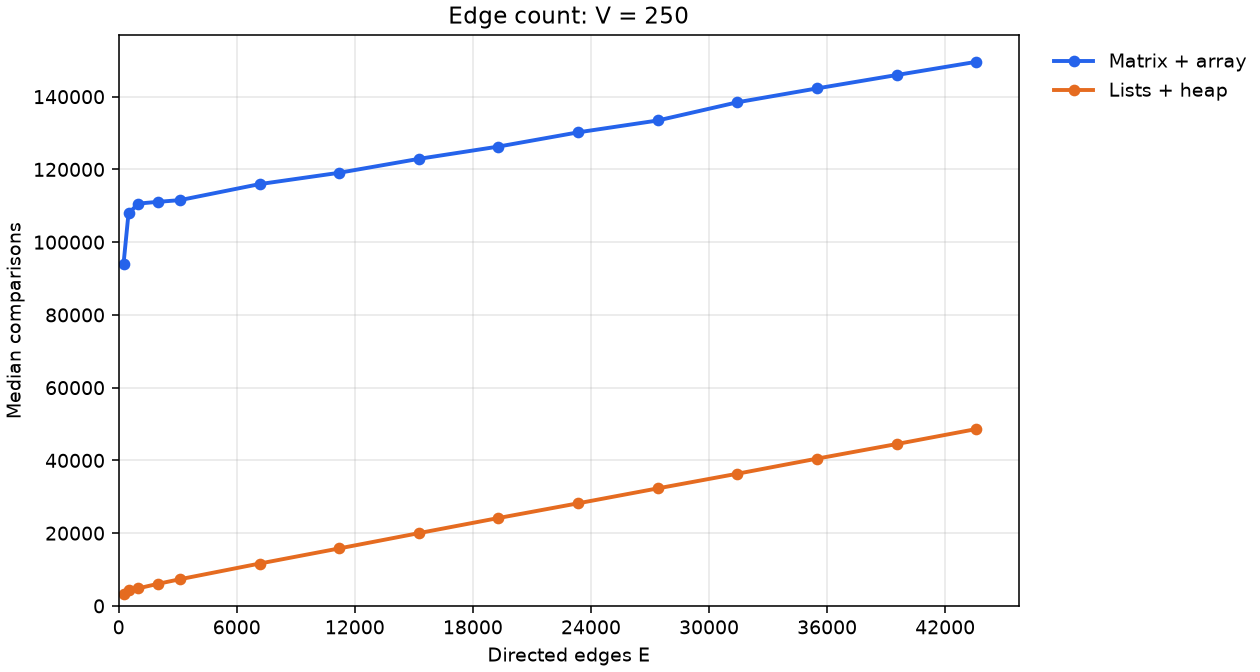

In [26]:
chart(f"Edge count: V = {FIXED_V}", "Directed edges E", [
    ('Matrix + array', [(r['E'], r['matrix']) for r in edge_results], '#2563eb', False),
    ('Lists + heap', [(r['E'], r['heap']) for r in edge_results], '#e56b20', False)])

**Analysis:** At V = 250, E increases from 249 to 43,575, matrix counts change from **94,124 to 149,576**, while heap counts change from **3,256 to 48,615**. The matrix/heap comparison ratio changes from **28.9× to 3.1×**. Adding edges increases the common relaxation component in both implementations. Matrix scans stay fixed at this V, while heap ordering counts depend on the graph. The ratio shows how their counted work changes as the same vertices become more connected. A smaller count means fewer defined decisions, not necessarily proportionally faster execution. Counts are deterministic for a fixed graph; the reported range comes from different graphs.

In [27]:
print("Descriptive log-log slopes (comparisons roughly proportional to V^slope):")
for family, rows in vertex_results.items():
    print(f"{family}: matrix {log_slope(rows, 'matrix'):.2f}; heap {log_slope(rows, 'heap'):.2f}")
    first, last = rows[0], rows[-1]
    print(f"  At V={last['V']}, matrix/heap = {last['comparison_ratio']:.2f}.")
    print("  Matrix comparisons / V²:", [round(r['matrix'] / r['V']**2, 7) for r in rows])
    print("  Heap comparisons / ((V+E) log₂V):", [round(r['heap'] / ((r['V']+r['E'])*math.log2(r['V'])), 7) for r in rows])
print()
for r in edge_results:
    winner = 'heap' if r['comparison_ratio'] > 1 else 'matrix'
    print(f"V={r['V']}, E={r['E']}: {winner} uses fewer comparisons; matrix/heap={r['comparison_ratio']:.2f}")

Descriptive log-log slopes (comparisons roughly proportional to V^slope):
sparse: matrix 1.99; heap 1.19
  At V=400, matrix/heap = 35.62.
  Matrix comparisons / V²: [1.798, 1.7749333, 1.7577, 1.761024, 1.7576, 1.747298, 1.760925, 1.7570173, 1.75856, 1.7476231, 1.7535222, 1.7427598, 1.7546776, 1.7663076, 1.7356]
  Heap comparisons / ((V+E) log₂V): [0.5838207, 0.5811696, 0.5715807, 0.5716514, 0.5694799, 0.5688433, 0.5700657, 0.5743414, 0.5678035, 0.5662124, 0.5670113, 0.5714636, 0.5644161, 0.5656426, 0.5636229]
dense: matrix 1.99; heap 1.81
  At V=400, matrix/heap = 5.70.
  Matrix comparisons / V²: [2.0392, 2.0535111, 2.0259, 2.039232, 2.0311111, 2.0177306, 2.015525, 2.0235654, 2.018368, 2.0237488, 2.0026444, 2.0283456, 2.0106531, 2.0180409, 2.0033375]
  Heap comparisons / ((V+E) log₂V): [0.3006482, 0.2485665, 0.2193989, 0.19987, 0.1867475, 0.1765585, 0.1681962, 0.1610976, 0.1558913, 0.1504936, 0.1467758, 0.1433978, 0.1401236, 0.1375478, 0.13483]

V=250, E=249: heap uses fewer comparison

| Property | Matrix + array | Adjacency lists + indexed heap |
|---|---|---|
| Worst-case time | $\Theta(V^2)$ | $O((V+E)\log V)$ |
| Graph storage | $\Theta(V^2)$ | $O(V+E)$ |
| Auxiliary storage | $O(V)$ | $O(V)$ |
| Sparse graphs, $E=O(V)$ | $\Theta(V^2)$ | $O(V\log V)$ |
| Dense graphs, $E=\Theta(V^2)$ | $\Theta(V^2)$ | $O(V^2\log V)$ upper bound |

**Sparse graphs:** scanning only actual edges reduces the counted work. Matrix edge checks and array minimum searches are quadratic in V, whereas the heap has an O(V log V) comparison bound when E = 3V.

**Dense graphs:** both algorithms perform E relaxation comparisons. The heap may still use fewer comparisons because many edges do not trigger decrease-key, despite its larger worst-case upper bound. Use the measured ratios rather than assuming a crossover must occur.

**Holding V fixed:** matrix edge checks and minimum searches stay constant; relaxation comparisons increase exactly with E in both algorithms. The array removal search and heap ordering counts depend on the graph's shortest-path exploration order.

**Limits of the evidence:** comparison counts measure the decisions defined in part (a), not all operations or runtime. A heap ordering decision and a matrix edge check need not cost the same. Counts do not measure memory, list shifting, graph construction, or validation. These experiments use one starting vertex, positive weights, and chain-connected directed graphs. Median/min/max values describe variation across three graphs, not timing uncertainty, and finite measurements do not prove asymptotic bounds.

In [28]:
# Keep comparison totals and per-graph category breakdowns available for export.
results = {'metric': 'algorithm_level_comparisons',
           'count_categories': list(comparison_counter()),
           'config': {'seed': SEED, 'vertices': VERTICES, 'fixed_v': FIXED_V,
                      'graph_trials': GRAPH_TRIALS},
           'vertex_sweep': vertex_results, 'edge_sweep': edge_results,
           'runtime': {'python': sys.version, 'platform': platform.platform(), 'numpy': np.__version__}}
print("All implementations, correctness checks, comparison experiments, and plots completed.")

All implementations, correctness checks, comparison experiments, and plots completed.
